In [5]:
!pip install ultralytics
from ultralytics import YOLO
model = YOLO("yolo11s-seg.pt")

In [7]:
import yaml
with open('/kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/dataset.yaml','r') as f:
    data=yaml.safe_load(f)
    print(data['names'])

{0: 'Lane'}


In [6]:
class_names=['Lane']

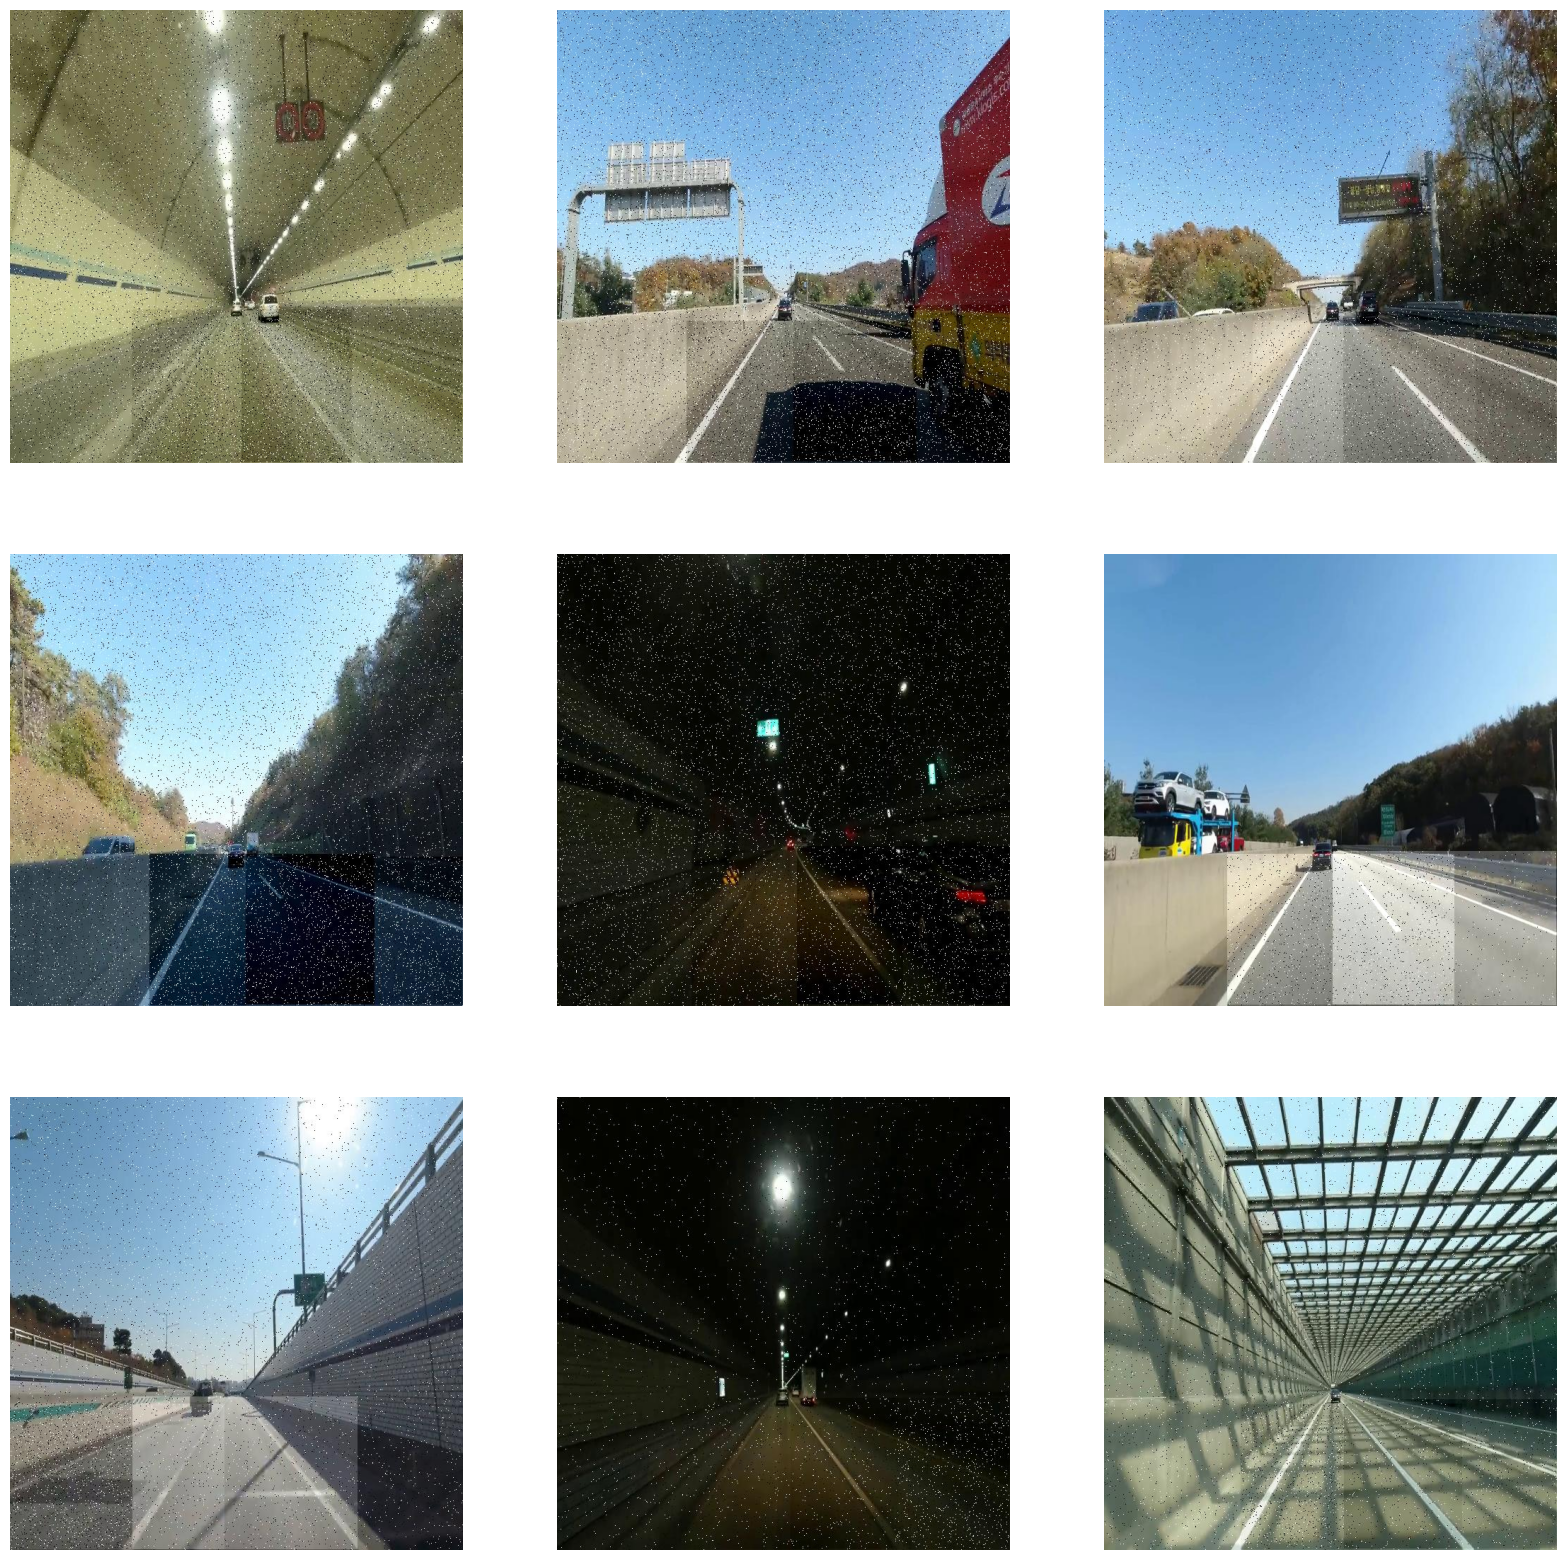

In [10]:
import random
import cv2
import os
import matplotlib.pyplot as plt

image_dir = '/kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/train/images'
image_files = os.listdir(image_dir)
random_images = random.sample(image_files, 9)
label_files = '/kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/train/labels'

fig, axs = plt.subplots(3, 3, figsize=(20, 20))

for i, image_file in enumerate(random_images):
    image_path = os.path.join(image_dir, image_file)
    image = cv2.imread(image_path)
    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(label_files, label_file)
    
    with open(label_path, "r") as f:
        labels = f.read().strip().split("\n")

    for label in labels:
        if len(label.split()) != 5:
            continue
        class_id, x_center, y_center, width, height = map(float, label.split())
        x_min = int((x_center - width / 2) * image.shape[1])
        y_min = int((y_center - height / 2) * image.shape[0])
        x_max = int((x_center + width / 2) * image.shape[1])
        y_max = int((y_center + height / 2) * image.shape[0])

        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)

        text_scale = max(1.5, min(image.shape[1], image.shape[0]) / 700)
        text_thickness = max(1, int(text_scale * 4))
        classe = class_names[int(class_id)]
        cv2.putText(
            image,
            classe,
            (x_min, max(y_min - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            text_scale,
            (0, 0, 255),
            text_thickness,
            cv2.LINE_AA,
        )
    row = i // 3 
    col = i % 3  

    axs[row, col].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axs[row, col].axis('off')

plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.show()

In [11]:
with open('/kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/dataset.yaml','r') as f:
    print(yaml.safe_load(f))

{'train': '/kaggle/working/dataset/train/images', 'val': '/kaggle/working/dataset/val/images', 'test': '/kaggle/working/dataset/test/images', 'nc': 1, 'names': {0: 'Lane'}}


In [12]:
import yaml
data = {
    'train': '/kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/train/images',
    'val': '/kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/val/images',
    'test': '/kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/test/images',
    'nc': 1,
    'names': {0: 'Lane'}
}
with open('dataset_config.yaml', 'w') as file:
    yaml.dump(data, file, default_flow_style=False)

print("YAML file 'dataset_config.yaml' created successfully.")


YAML file 'dataset_config.yaml' created successfully.


In [13]:
model=YOLO('yolo11s-seg.pt')
model.train(data='/kaggle/working/dataset_config.yaml',epochs=20,batch=16,imgsz=640)

Ultralytics 8.3.237 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=T

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79cd946e1e10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
import os
from IPython.display import Image, display
path = '/kaggle/working/runs/detect/train3'

images = [f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))]

for i in images:
    display(Image(filename=os.path.join(path, i)))


In [ ]:
metrics = model.val(split='val')

print(f"Mean Average Precision @.5:.95 : {metrics.box.map}")    
print(f"Mean Average Precision @ .50   : {metrics.box.map50}") 
print(f"Mean Average Precision @ .70   : {metrics.box.map75}")
print("recall : ",metrics.box.r)
print(metrics.box.f1)
print(metrics.box.maps)


image 1/1 /kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/test/images/i947.jpg: 640x640 2 Lanes, 10.8ms
Speed: 1.8ms preprocess, 10.8ms inference, 12.0ms postprocess per image at shape (1, 3, 640, 640)


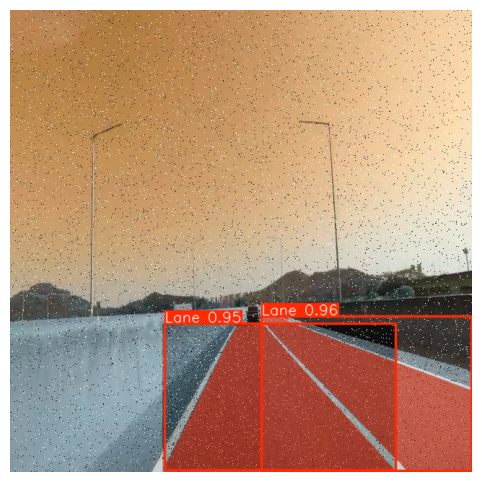


image 1/1 /kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/test/images/i499.jpg: 640x640 2 Lanes, 11.4ms
Speed: 1.8ms preprocess, 11.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


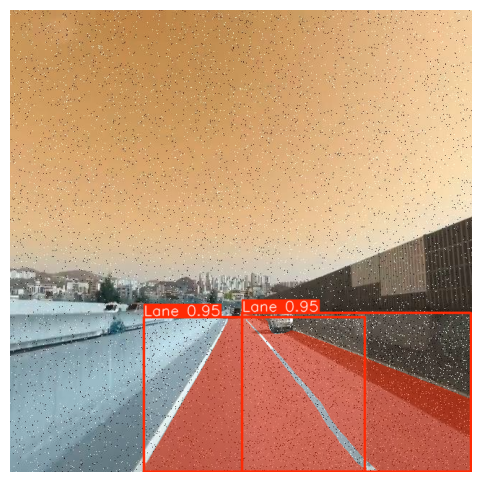


image 1/1 /kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/test/images/i557.jpg: 640x640 2 Lanes, 11.1ms
Speed: 1.8ms preprocess, 11.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


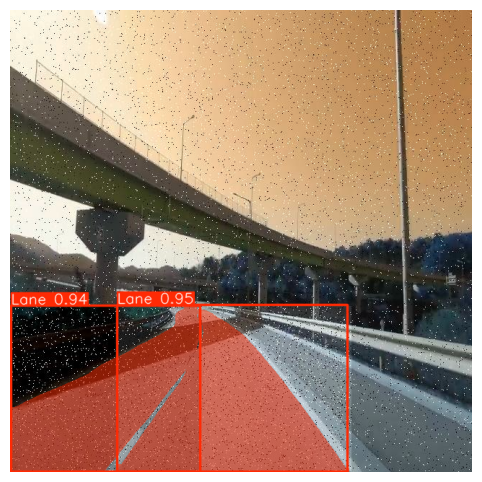


image 1/1 /kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/test/images/i758.jpg: 640x640 2 Lanes, 10.7ms
Speed: 1.7ms preprocess, 10.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


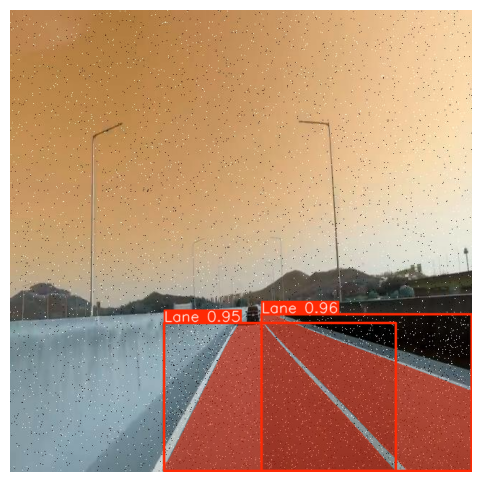


image 1/1 /kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/test/images/i207.jpg: 640x640 2 Lanes, 10.3ms
Speed: 1.5ms preprocess, 10.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


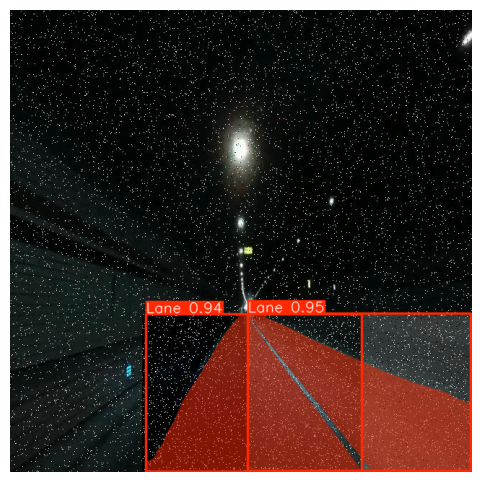

In [14]:
image_dir='/kaggle/input/road-lane-segmentation-imgs-and-labels/dataset/test/images'
all_images = os.listdir(image_dir)
selected_images = all_images[:5]

for img_name in selected_images:
    img_path = os.path.join(image_dir, img_name) 
    results = model.predict(img_path)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
    for result in results:
        plotted_img = result.plot()
        plt.figure(figsize=(8, 6))  
        plt.imshow(plotted_img)    
        plt.axis('off')             
        plt.show() 